In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## Load and transform run

In [2]:
FOLDER = "18-03-26--18_43_32/mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb745d3f-305a-466e-9ebb-c57e2e06ee0f}.pkl"

data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

## Plots

## Plot: GRS by user

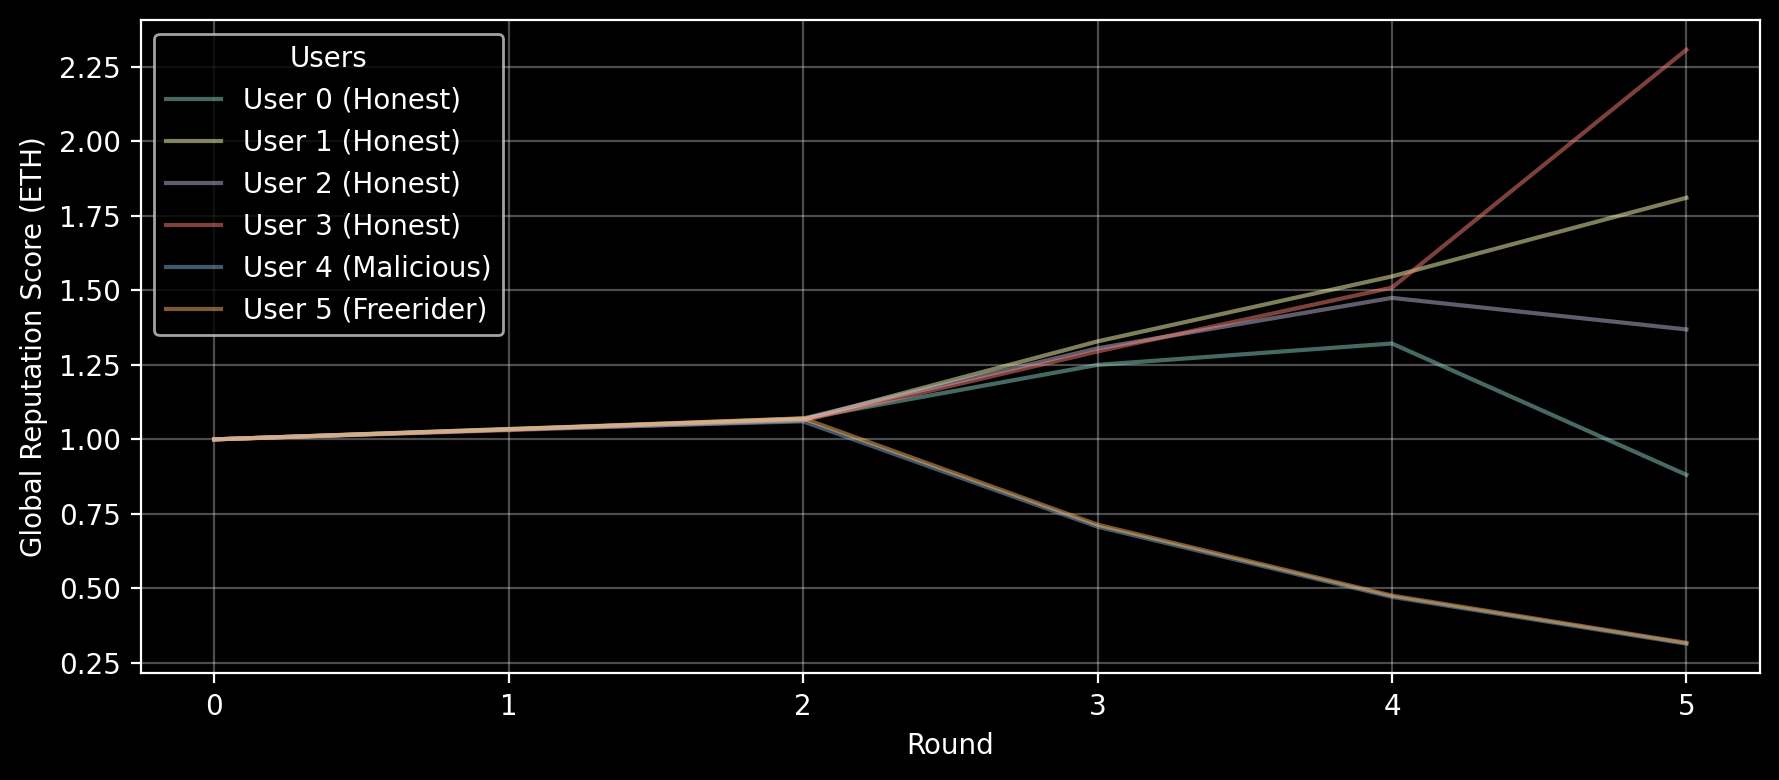

In [3]:
data = res['users']

# data[['grs', 'user_id', 'round']]

agg = grs_by_user(data)

fig = plot_grs_by_user(agg)

## Plot: Model Performance by Global Accuracy for aggregation strategies

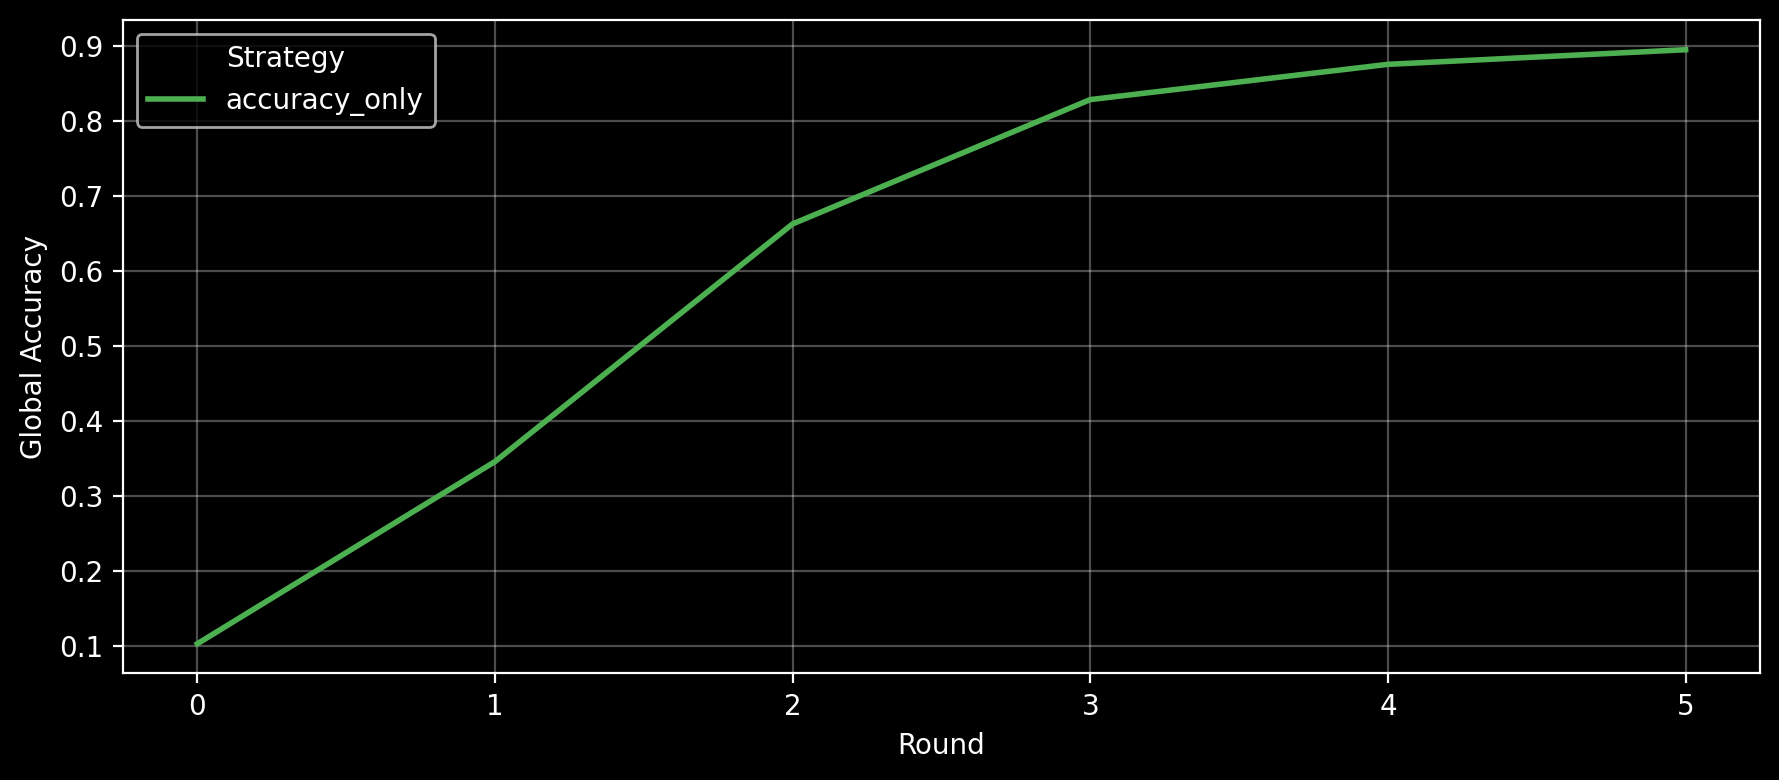

In [4]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_acc_by_aggregation_strategy(data, res['metadata'])


fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

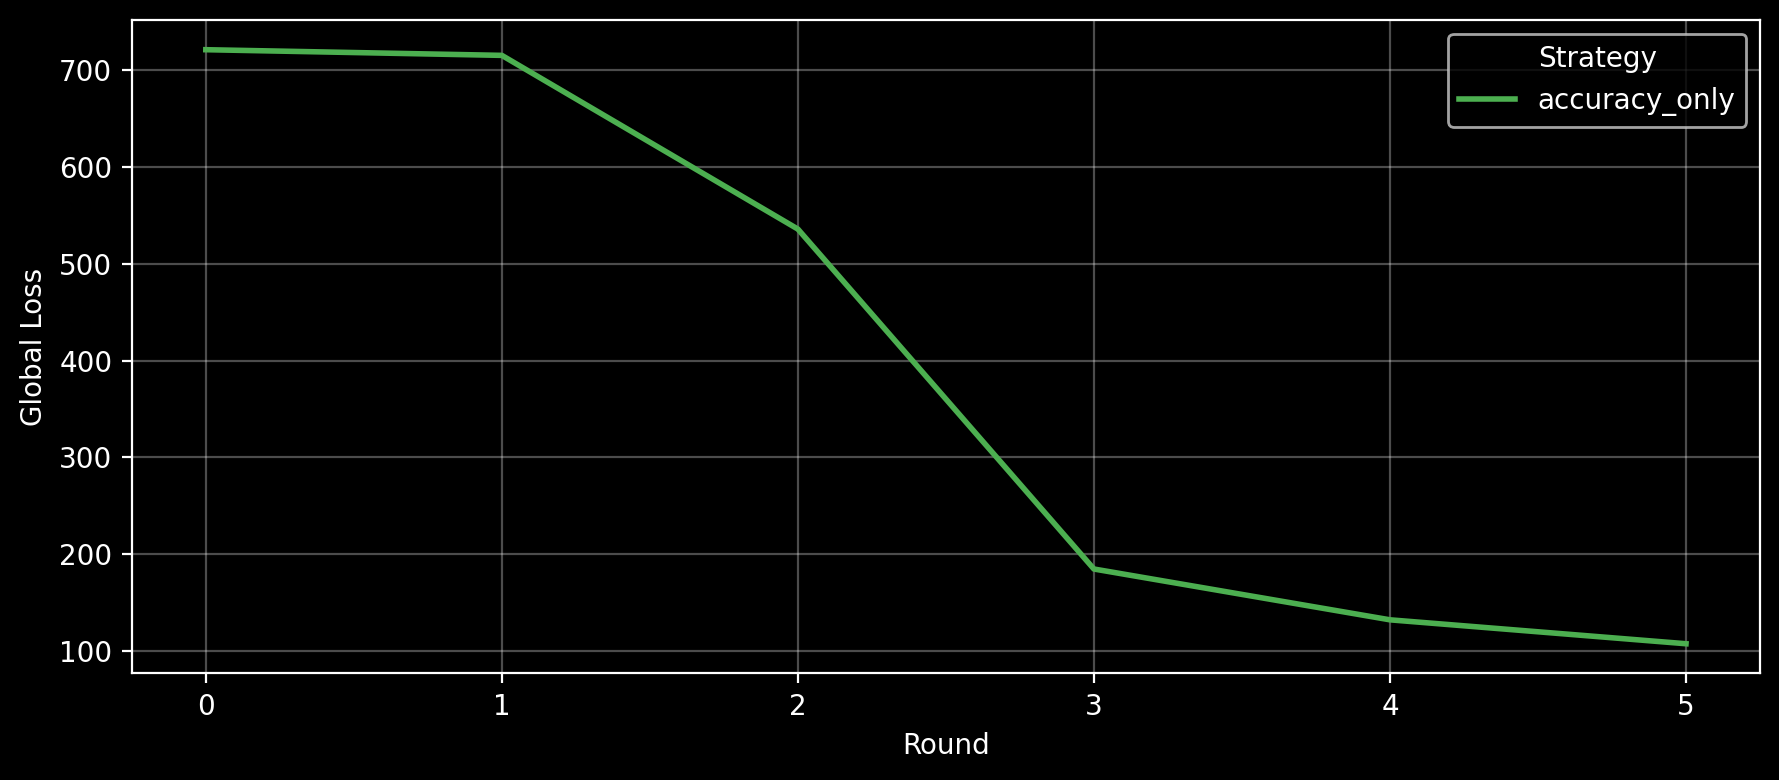

In [5]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_loss_by_aggregation_strategy(data, res['metadata'])
fig = plot_global_loss_by_aggregation_strategy(vals)

## Query: Runtime warnings

In [8]:
# data = res['setup'] does not work

data = res['warnings']


res['contributions']

,experiment_id,round,user_id,user_address,contribution_score,user_mad_avg,current_excluded_values,current_accepted_values,current_mad_median,current_mad_value,current_mad_max_deviation,prev_avg_round_val_after_mad,previous_excluded_values,previous_accepted_values,previous_mad_median,previous_mad_value,previous_mad_max_deviation
0,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,0,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,166732830488288991,7267.500000,[7050.0],"[7190.0, 7310.0, 7240.0, 7330.0]",7240.0,70.0,114.158636,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
1,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,1,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,174379263055324973,7550.000000,"[7720.0, 7760.0]","[7530.0, 7560.0, 7560.0]",7560.0,30.0,48.925130,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
2,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,2,0x9f886a6bAD6DfD9409e05eE6743184feE0338d01,164418600454725893,7182.000000,[],"[7190.0, 7000.0, 6990.0, 7310.0, 7420.0]",7190.0,190.0,309.859155,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
3,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,3,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,155071456927352108,6836.666667,"[6690.0, 7180.0]","[6820.0, 6880.0, 6810.0]",6820.0,60.0,97.850259,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
4,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,4,0x1930426B96FD9D0Ca399436995100315E3a37118,167274170847017206,7287.500000,[7660.0],"[7340.0, 7150.0, 7470.0, 7190.0]",7340.0,150.0,244.625649,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
5,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,1,5,0xcA8c42e4A7725bbd27d2d6911c579cc8f6d51913,172123678227290771,7466.666667,"[7650.0, 7620.0]","[7500.0, 7450.0, 7450.0]",7500.0,50.0,81.541883,1107.500000,"[1280.0, 930.0]","[1140.0, 1140.0, 1080.0, 1070.0]",1110.0,35.0,57.079318
6,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,2,0,0x909362B1290E04f28ab421261B8Bdd1E5ffBA276,181023484383121491,6487.500000,[6100.0],"[6310.0, 6570.0, 6430.0, 6640.0]",6430.0,140.0,228.317272,3295.000000,"[3230.0, 3810.0]","[3300.0, 3330.0, 3300.0, 3250.0]",3300.0,40.0,65.233506
7,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,2,1,0xc45595219926EC8Ba6892f1AE526d76cdAb7e1E2,155838019184425635,6043.333333,"[6240.0, 6470.0]","[6070.0, 6020.0, 6040.0]",6070.0,50.0,81.541883,3295.000000,"[3230.0, 3810.0]","[3300.0, 3330.0, 3300.0, 3250.0]",3300.0,40.0,65.233506
8,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,2,2,0x9f886a6bAD6DfD9409e05eE6743184feE0338d01,186552001134054734,6585.000000,[6950.0],"[6650.0, 6440.0, 6510.0, 6740.0]",6650.0,140.0,228.317272,3295.000000,"[3230.0, 3810.0]","[3300.0, 3330.0, 3300.0, 3250.0]",3300.0,40.0,65.233506
9,mnist-accuracy_only-3-1.0-3-1.0-True-False-{fb...,2,3,0x1996Be88f24c47FA5C10D70FaA3489c9F9EcA0cd,160752256296366302,6130.000000,"[5970.0, 6450.0]","[6200.0, 6060.0, 6130.0]",6130.0,70.0,114.158636,3295.000000,"[3230.0, 3810.0]","[3300.0, 3330.0, 3300.0, 3250.0]",3300.0,40.0,65.233506
